In [ ]:
# Google Colab Setup
!pip install torch torchvision seaborn

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 23.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# Parámetros físicos y numéricos
L = 1.0  # Longitud del dominio
T_final = 1.0  # Tiempo final
Nx = 100  # Puntos espaciales
Nt = 100  # Puntos temporales
alpha = 0.01  # Difusividad

x = np.linspace(0, L, Nx).reshape(-1, 1)
t = np.linspace(0, T_final, Nt).reshape(-1, 1)
X, T = np.meshgrid(x, t)
X = X.reshape(-1, 1)
T = T.reshape(-1, 1)

In [ ]:
# Red neuronal sin PINNs
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat((x, t), dim=1)
        return self.net(inputs)

# Red neuronal para PINNs
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat((x, t), dim=1)
        return self.net(inputs)

In [ ]:
# Función de pérdida basada en la ecuación de difusión
def loss_pde(model, x, t):
    x.requires_grad = True
    t.requires_grad = True
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    return torch.mean((u_t - alpha * u_xx) ** 2)

# Entrenar red neuronal sin PINNs
def train_nn():
    model = SimpleNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    x_train = torch.FloatTensor(X).to(device)
    t_train = torch.FloatTensor(T).to(device)
    target = torch.sin(torch.tensor(np.pi * X, dtype=torch.float32, device=device))  # Solución esperada aproximada
    criterion = nn.MSELoss()

    for epoch in range(5000):
        optimizer.zero_grad()
        output = model(x_train, t_train)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()-
        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return model

In [ ]:
# Entrenar PINN
def train_pinn():
    model = PINN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    x_train = torch.FloatTensor(X).to(device)
    t_train = torch.FloatTensor(T).to(device)

    for epoch in range(5000):
        optimizer.zero_grad()
        loss = loss_pde(model, x_train, t_train)
        loss.backward(retain_graph=True)
        optimizer.step()
        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return model

# Resolver por diferencias finitas
def solve_fd():
    U = np.zeros((Nx, Nt))
    U[:, 0] = np.sin(np.pi * x[:, 0])  # Condición inicial
    dx = L / (Nx - 1)
    dt = T_final / (Nt - 1)
    r = alpha * dt / dx**2

    for n in range(0, Nt - 1):
        for i in range(1, Nx - 1):
            U[i, n+1] = U[i, n] + r * (U[i+1, n] - 2*U[i, n] + U[i-1, n])
    return U

In [ ]:

# Visualizar resultados
def plot_results(models, titles):
    x_test = torch.FloatTensor(x).to(device)
    t_test = torch.FloatTensor(np.full((Nx, 1), T_final)).to(device)

    plt.figure(figsize=(15, 5))
    for i, (model, title) in enumerate(zip(models, titles)):
        with torch.no_grad():
            u_pred = model(x_test, t_test).cpu().numpy().flatten()

        plt.subplot(1, 3, i+1)
        plt.plot(x, u_pred, label=title)
        plt.xlabel("x")
        plt.ylabel("Temperatura u(x,t)")
        plt.legend()
        plt.title(title)
    plt.show()

    # Heatmaps
    for i, (model, title) in enumerate(zip(models, titles)):
        x_grid, t_grid = np.meshgrid(x.flatten(), t.flatten())
        u_pred = np.zeros_like(x_grid)

        for j in range(len(x.flatten())):
            for k in range(len(t.flatten())):
                x_t = torch.FloatTensor([[x_grid[j, k], t_grid[j, k]]]).to(device)
                with torch.no_grad():
                    u_pred[j, k] = model(x_t[:, 0:1], x_t[:, 1:2]).cpu().numpy()

        plt.figure(figsize=(8, 6))
        sns.heatmap(u_pred.T, cmap="coolwarm", xticklabels=10, yticklabels=10, cbar_kws={'label': 'Temperatura'})
        plt.xlabel("Posición x")
        plt.ylabel("Tiempo t")
        plt.title(f"Distribución de Temperatura: {title}")
        plt.show()

Epoch 0, Loss: 0.603378
Epoch 500, Loss: 0.000078
Epoch 1000, Loss: 0.000048
Epoch 1500, Loss: 0.000037
Epoch 2000, Loss: 0.000034
Epoch 2500, Loss: 0.000028
Epoch 3000, Loss: 0.000020
Epoch 3500, Loss: 0.000075
Epoch 4000, Loss: 0.000014
Epoch 4500, Loss: 0.000013
Epoch 0, Loss: 0.002338
Epoch 500, Loss: 0.000000
Epoch 1000, Loss: 0.000000
Epoch 1500, Loss: 0.000000
Epoch 2000, Loss: 0.000000
Epoch 2500, Loss: 0.000000
Epoch 3000, Loss: 0.000000
Epoch 3500, Loss: 0.000000
Epoch 4000, Loss: 0.000000
Epoch 4500, Loss: 0.000000


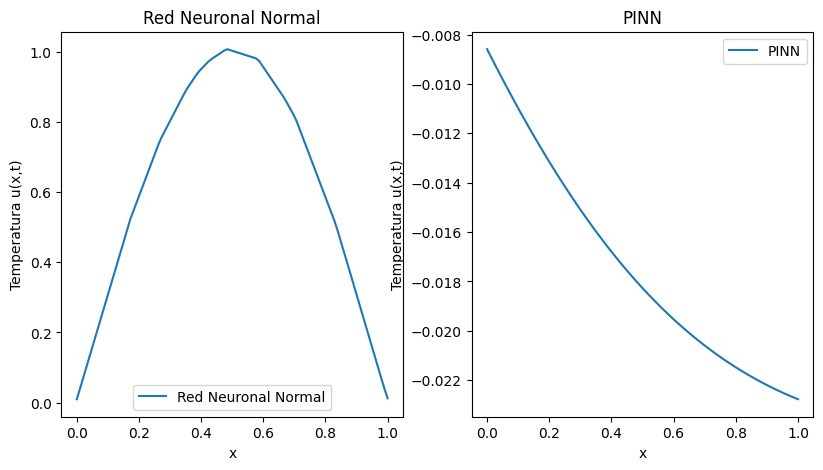

<ipython-input-6-6dc3c248980e>:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_pred[j, k] = model(x_t[:, 0:1], x_t[:, 1:2]).cpu().numpy()


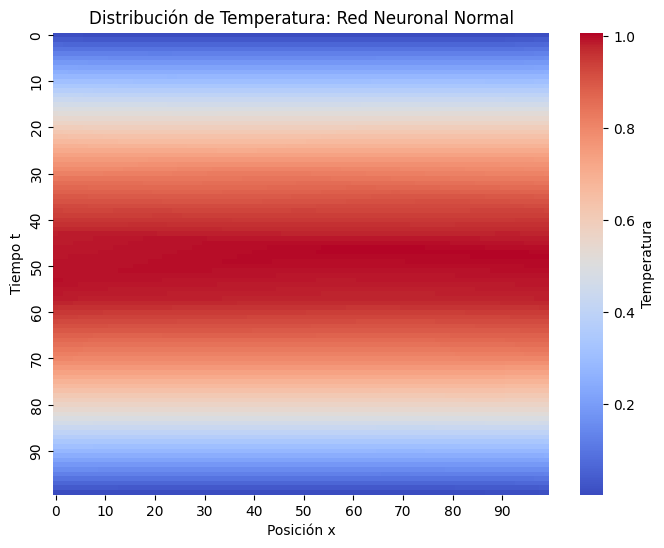

<ipython-input-6-6dc3c248980e>:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_pred[j, k] = model(x_t[:, 0:1], x_t[:, 1:2]).cpu().numpy()


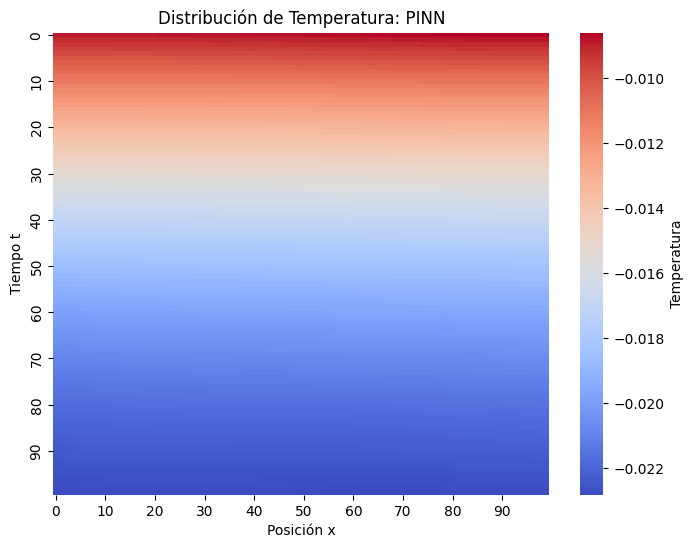

In [ ]:

if __name__ == "__main__":
    fd_solution = solve_fd()
    model_nn = train_nn()
    model_pinn = train_pinn()
    plot_results([model_nn, model_pinn], ["Red Neuronal Normal", "PINN"])
